# Exploratory Data Analysis — Serif Health Take-Home
## HPT × TiC Price Transparency Dataset

### Purpose

This notebook explores two federally-mandated healthcare price transparency datasets:
the Hospital Price Transparency (HPT) files and the Transparency in Coverage (TiC) 
payer machine-readable files (MRFs). 

The goals of this EDA are:

1. **Schema understanding** — examine the structure, fields, and data types of each 
   dataset independently before attempting any integration
2. **Data quality assessment** — identify missing values, inconsistencies, encoding 
   errors, and normalization needs that must be addressed before joining
3. **Join feasibility** — determine which fields can serve as reliable keys for matching 
   records across the two datasets, and where ambiguity requires judgment calls
4. **Rate distribution analysis** — understand the range, spread, and patterns of 
   negotiated rates across hospitals, payers, and procedure codes
5. **Insight generation** — surface preliminary findings that inform downstream 
   matching strategy and potential product use cases for Serif's customers

### Dataset Context

HPT files are published by hospitals and document their negotiated rates with each 
payer across all billable services. TiC MRFs are published by payers and document 
the same negotiated rates from the payer's perspective. In theory, both sides are 
reporting the same underlying contracts — in practice, schema differences, update 
timing gaps, rate methodology variations, and inconsistent compliance make direct 
comparison a non-trivial data engineering and modeling problem.

This EDA is the foundation for building a principled matching approach that goes 
beyond a simple deterministic join.

## Phase 1 — Schema Understanding

Goal: Understand the structure of each dataset independently before any integration.
This includes shape, column definitions, data types, and missing value patterns.
A clear schema understanding is the foundation for all downstream cleaning and joining decisions.

In [1]:
import pandas as pd
import numpy as np

# Load both datasets
hpt = pd.read_csv("hpt_extract_20250213.csv")
tic = pd.read_csv("tic_extract_20250213.csv")

print(f"HPT: {hpt.shape[0]} rows × {hpt.shape[1]} columns")
print(f"TiC: {tic.shape[0]} rows × {tic.shape[1]} columns")

HPT: 2950 rows × 22 columns
TiC: 222 rows × 17 columns


In [2]:
# look at HPT first few rows
hpt.head(3)

,source_file_name,hospital_id,hospital_name,last_updated_on,hospital_state,license_number,payer_name,plan_name,code_type,raw_code,...,modifiers,standard_charge_gross,standard_charge_discounted_cash,standard_charge_negotiated_dollar,standard_charge_negotiated_percentage,standard_charge_min,standard_charge_max,standard_charge_methodology,additional_payer_notes,additional_generic_notes
0,13-1740114_montefiore-medical-center_standardc...,62915ae8-8d64-4e2f-b05f-b18edde57a3d,Montefiore Medical Center,2024-07-01,NY,13-1740114,Aetna,Medicare,CPT,99283,...,NaN,NaN,NaN,323.34,NaN,83.78,1009.22,fee schedule,NaN,NaN
1,13-1740114_montefiore-medical-center_standardc...,62915ae8-8d64-4e2f-b05f-b18edde57a3d,Montefiore Medical Center,2024-07-01,NY,13-1740114,HealthFirst,Commercial Enrollees,CPT,43239,...,NaN,NaN,NaN,1037.65,NaN,165.40,3206.34,fee schedule,NaN,NaN
2,13-1740114_montefiore-medical-center_standardc...,62915ae8-8d64-4e2f-b05f-b18edde57a3d,Montefiore Medical Center,2024-07-01,NY,13-1740114,Aetna,Commercial,CPT,43239,...,NaN,NaN,NaN,1246.73,NaN,1246.73,1394.79,fee schedule,NaN,NaN


In [3]:
# look at Tic first few rows
tic.head(3)

,payer,network_name,network_id,network_year_month,network_region,code,code_type,ein,taxonomy_filtered_npi_list,modifier_list,billing_class,place_of_service_list,negotiation_type,arrangement,rate,cms_baseline_schedule,cms_baseline_rate
0,unitedhealthcare,choice-plus,592bc118-0dac-4f38-949c-11dc9b3a3879,202501,USA,872,MS-DRG,131740114,"1003990763,1023202793,1063525152,1063606739,10...",NaN,institutional,NaN,negotiated,ffs,15902.00,IPPS,6829.75
1,unitedhealthcare,choice-plus,592bc118-0dac-4f38-949c-11dc9b3a3879,202501,USA,99283,CPT,131624096,"1003255670,1245759711,1487026522,1598095267,16...",NaN,professional,11,negotiated,ffs,123.86,PFS_NONFACILITY_1320201,76.89
2,unitedhealthcare,choice-plus,592bc118-0dac-4f38-949c-11dc9b3a3879,202501,USA,43239,CPT,131740114,"1700348620,1700892056,1922539964,1942685292",NaN,professional,11,negotiated,ffs,993.92,PFS_NONFACILITY_1320202,424.76


In [4]:
# HPT column names, data types, and sample values
print("=== HPT Schema ===")
for col in hpt.columns:
    sample = hpt[col].dropna().iloc[0] if hpt[col].notna().any() else "all null"
    print(f"  {col:<45} {str(hpt[col].dtype):<12} sample: {sample}")

=== HPT Schema ===
  source_file_name                              str          sample: 13-1740114_montefiore-medical-center_standardcharges.csv.gz
  hospital_id                                   str          sample: 62915ae8-8d64-4e2f-b05f-b18edde57a3d
  hospital_name                                 str          sample: Montefiore Medical Center
  last_updated_on                               str          sample: 2024-07-01
  hospital_state                                str          sample: NY
  license_number                                str          sample: 13-1740114
  payer_name                                    str          sample: Aetna
  plan_name                                     str          sample: Medicare
  code_type                                     str          sample: CPT
  raw_code                                      str          sample: 99283
  description                                   str          sample: EMERGENCY DEPT VISIT LOW MDM
  setting           

In [5]:
# TiC column names, data types, and sample values
print("=== TiC Schema ===")
for col in tic.columns:
    sample = tic[col].dropna().iloc[0] if tic[col].notna().any() else "all null"
    print(f"  {col:<45} {str(tic[col].dtype):<12} sample: {sample}")

=== TiC Schema ===
  payer                                         str          sample: unitedhealthcare
  network_name                                  str          sample: choice-plus
  network_id                                    str          sample: 592bc118-0dac-4f38-949c-11dc9b3a3879
  network_year_month                            int64        sample: 202501
  network_region                                str          sample: USA
  code                                          int64        sample: 872
  code_type                                     str          sample: MS-DRG
  ein                                           int64        sample: 131740114
  taxonomy_filtered_npi_list                    str          sample: 1003990763,1023202793,1063525152,1063606739,1073708392,1205021490,1235324534,1265591168,1275763203,1326232042,1427185057,1437348455,1457406621,1487848156,1497940670,1538243209,1588859870,1720219231,1780878405,1851340608,1891154886,1942580840,1952476988
  modifie

In [6]:
# Missing value count and percentage for both datasets
def missing_summary(df, name):
    total = len(df)
    summary = pd.DataFrame({
        "missing_count": df.isnull().sum(),
        "missing_pct": (df.isnull().sum() / total * 100).round(1)
    })
    summary = summary[summary["missing_count"] > 0].sort_values(
        "missing_pct", ascending=False
    )
    print(f"=== {name} Missing Values ===")
    print(summary.to_string())
    print()

missing_summary(hpt, "HPT")
missing_summary(tic, "TiC")

=== HPT Missing Values ===
                                       missing_count  missing_pct
modifiers                                       2916         98.8
additional_generic_notes                        2908         98.6
standard_charge_min                             2322         78.7
standard_charge_max                             2322         78.7
standard_charge_negotiated_percentage           2280         77.3
standard_charge_gross                            943         32.0
standard_charge_discounted_cash                  930         31.5
additional_payer_notes                           693         23.5
standard_charge_negotiated_dollar                426         14.4
standard_charge_methodology                      214          7.3

=== TiC Missing Values ===
                            missing_count  missing_pct
modifier_list                         215         96.8
place_of_service_list                  25         11.3
taxonomy_filtered_npi_list              4          1.8

In [7]:
# Investigate missing negotiated rate in HPT for big-3 payers (raw payer names)
big3_raw = ["Aetna", "aetna", "Cigna", "cigna", "United", "UHC", "uhc", "United Healthcare"]

missing_big3 = hpt[
    hpt["payer_name"].isin(big3_raw) &
    hpt["standard_charge_negotiated_dollar"].isna()
]

print(f"Rows with missing negotiated rate (big-3): {len(missing_big3)}")

print(missing_big3[[
    "hospital_name", "payer_name", 
    "standard_charge_gross", "standard_charge_negotiated_percentage",
    "standard_charge_methodology"
]].to_string())

Rows with missing negotiated rate (big-3): 17
     hospital_name payer_name  standard_charge_gross  standard_charge_negotiated_percentage      standard_charge_methodology
466    NYU Langone        uhc               32829.50                                    NaN                              NaN
471    NYU Langone        uhc                1464.39                                    NaN                              NaN
613    NYU Langone        uhc                1464.39                                    NaN                              NaN
934    NYU Langone        uhc                5106.17                                    NaN                              NaN
1126   NYU Langone        uhc               32829.50                                    NaN                              NaN
1172   NYU Langone        uhc                2182.13                                    NaN                     Fee Schedule
1180   NYU Langone        uhc               32829.50                           

### Schema Observations
**Hospital identifier:**
- HPT provides three identifiers: hospital_id (UUID), hospital_name, and 
license_number.
- TiC uses EIN only with no hospital name. 
- License_number and EIN can be matched by referring to public records, but requires datatype matching and formatting normalization  before joining.

**HPT rate columns:**
Three rate types exist: gross charge, discounted cash, and negotiated dollar. 
For this project only `standard_charge_negotiated_dollar` is relevant — it 
represents the payer-specific contracted rate and is the direct equivalent 
of the TiC rate column. Gross charge and cash price are not compared with TiC rate.

**Missing values:**
- Critical key columns (hospital identifier, billing code, payer identifier etc.) have 
  zero missing values in both files — solid foundation for matching
- Modifier columns are 97-99% missing in both files — expected in healthcare, 
  modifiers only apply to a subset of procedures. Other columns with many missing values such as additional_generic_notes (98.6%) and standard_charge_min/max (79%) have limited analytical value
- HPT has 426 missing values in standard_charge_negotiated_dollar — 
the primary rate column for comparison with TiC. One potential imputation 
approach is gross_charge × negotiated_percentage for rows where methodology 
is "percent of billed charges." However after filtering to big-3 payers only, missing negotiated rates drop 
to just 17 rows. Investigating these 17 rows reveals that none are 
recoverable via imputation — either the gross charge is also missing, or the 
methodology is not percentage-based, making the calculation impossible.
- Given the small volume and lack of imputation path, these 17 rows are not imputed. This is an acceptable tradeoff within the project scope — at 
scale, a more exhaustive imputation strategy would be warranted including 
deriving rates from min/max ranges or flagging for manual review.
  
**Dates:**
Both date columns are stored as strings in different formats — HPT uses `last_updated_on` 
(e.g. "2024-07-01") and TiC uses `network_year_month` (e.g. 202501 as integer). 
Both need conversion to datetime if temporal analysis is needed.


## Phase 2 — Data Quality Assessment

Goal: Identify inconsistencies, encoding errors, and normalization needs in each 
dataset before any integration. Focuses on unique values in key columns to surface 
naming inconsistencies, unexpected values, and fields that require cleaning.

**HPT dataset**

In [8]:
# HPT key columns — unique value inspection

print("hospital_id:", hpt["hospital_id"].unique())
print("hospital_name:", hpt["hospital_name"].unique())
print("license_number:", hpt["license_number"].unique())
print("setting:", hpt["setting"].unique())
print("raw_code:", hpt["raw_code"].unique())
print("code_type:", hpt["code_type"].unique())
print("standard_charge_methodology:", hpt["standard_charge_methodology"].unique())

hospital_id: <StringArray>
['62915ae8-8d64-4e2f-b05f-b18edde57a3d',
 '5954cbad-a7c5-43f7-b356-8f2ecdad579a',
 '40e6a8c8-a68c-4d28-b1d5-fa70d6d09636']
Length: 3, dtype: str
hospital_name: <StringArray>
['Montefiore Medical Center', 'The Mount Sinai Hospital', 'NYU Langone']
Length: 3, dtype: str
license_number: <StringArray>
['13-1740114', '330024', '7002053H']
Length: 3, dtype: str
setting: <StringArray>
['outpatient', 'both', 'inpatient']
Length: 3, dtype: str
raw_code: <StringArray>
['99283', '43239', '872', 'MS-DRG 872']
Length: 4, dtype: str
code_type: <StringArray>
['CPT', 'MS-DRG', 'LOCAL']
Length: 3, dtype: str
standard_charge_methodology: <StringArray>
[                   'fee schedule',                           'other',
                       'case rate',                        'per diem',
                    'Fee Schedule', 'percent of total billed charges',
                           'Other',                       'Case Rate',
                               nan, 'Percent of

In [9]:
# HPT text heavy columns inspection:
print("payer_name:", hpt["payer_name"].unique())
print("description:", hpt["description"].unique())

payer_name: <StringArray>
[                    'Aetna',               'HealthFirst',
                     'Cigna',                     'Oscar',
                'Healthcare',                    'United',
                    'Emblem',                    'Humana',
                   'Fidelis',               'Centerlight',
                  'Partners',                 'Northwell',
                   'Agewell',                 'MetroPlus',
                 'Longevity',                       'MVP',
                  'Hamaspik',                  'WellCare',
                    'Empire',                 'Elderplan',
                     'VNSNY',                       'Nat',
               'CentersPlan',                       'UHC',
            'VillageCareMAX',                    'Senior',
                    'Nippon',                  'Wellcare',
                  'SEIU1199',                    'Molina',
                 'Multiplan',                 'Magnacare',
                   'Centivo', 

In [10]:
# HPT code_type column has aabnormal code type 'Local' which needs further investigation
df_local = hpt[hpt["code_type"] == "LOCAL"].copy()

print(f"Total LOCAL rows: {len(df_local)}")
print(f"Hospital(s): {df_local['hospital_name'].unique()}")
print(f"Raw codes: {df_local['raw_code'].unique()}")
print(f"\nUnique descriptions:")
print(df_local["description"].unique())
print(f"\nSample rows:")
df_local[["hospital_name", "payer_name", "code_type", "raw_code", "description", 
          "setting", "standard_charge_negotiated_dollar"]].head(10)

Total LOCAL rows: 410
Hospital(s): <StringArray>
['NYU Langone']
Length: 1, dtype: str
Raw codes: <StringArray>
['43239']
Length: 1, dtype: str

Unique descriptions:
<StringArray>
['HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF ARTHROPATHY']
Length: 1, dtype: str

Sample rows:


,hospital_name,payer_name,code_type,raw_code,description,setting,standard_charge_negotiated_dollar
250,NYU Langone,oxford,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,NaN
253,NYU Langone,uhc,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,5170.65
271,NYU Langone,healthfirst,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,NaN
273,NYU Langone,bcbs,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,NaN
277,NYU Langone,cigna,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,10932.22
283,NYU Langone,aetna,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,6894.20
287,NYU Langone,fidelis,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,9136.45
302,NYU Langone,hip,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,13788.39
317,NYU Langone,healthplus,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,NaN
322,NYU Langone,hip,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,NaN


In [11]:
# Filter LOCAL code type rows for investigation
df_local = hpt[hpt["code_type"] == "LOCAL"].copy()

print(f"Total LOCAL rows: {len(df_local)}")
print(f"Hospital(s): {df_local['hospital_name'].unique()}")
print(f"Raw codes: {df_local['raw_code'].unique()}")
print(f"\nUnique descriptions:")
print(df_local["description"].unique())
print(f"\nSample rows:")
df_local[["hospital_name", "payer_name", "code_type", "raw_code", "description", 
          "setting", "standard_charge_negotiated_dollar"]].head(10)

Total LOCAL rows: 410
Hospital(s): <StringArray>
['NYU Langone']
Length: 1, dtype: str
Raw codes: <StringArray>
['43239']
Length: 1, dtype: str

Unique descriptions:
<StringArray>
['HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF ARTHROPATHY']
Length: 1, dtype: str

Sample rows:


,hospital_name,payer_name,code_type,raw_code,description,setting,standard_charge_negotiated_dollar
250,NYU Langone,oxford,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,NaN
253,NYU Langone,uhc,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,5170.65
271,NYU Langone,healthfirst,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,NaN
273,NYU Langone,bcbs,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,NaN
277,NYU Langone,cigna,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,10932.22
283,NYU Langone,aetna,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,6894.20
287,NYU Langone,fidelis,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,9136.45
302,NYU Langone,hip,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,13788.39
317,NYU Langone,healthplus,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,NaN
322,NYU Langone,hip,LOCAL,43239,HEAD HUM 19MM 50MM SHLDR UNIVERS STRL LF CUF A...,both,NaN


**Billing code and description inconsistency:** HPT contains a LOCAL code type exclusive to NYU Langone (410 rows). 
Despite sharing the same raw code `43239`, the descriptions reveal a completely 
different procedure — LOCAL rows describe "HEAD HUM 19MM 50MM SHLDR UNIVERS STRL 
LF CUF ARTHROPATHY", a shoulder reconstruction implant component, while CPT 43239 
is an upper GI endoscopy procedure. This is a clear data encoding error so LOCAL rows 
should be excluded from matching.

**TIC Dataset**

In [12]:
# TiC key columns — unique value inspection
print("payer:", tic["payer"].unique())
print("\nnetwork_name:", tic["network_name"].unique())
print("\nnetwork_id:", tic["network_id"].unique())
print("\ncode:", tic["code"].unique())
print("\ncode_type:", tic["code_type"].unique())
print("\nein:", tic["ein"].unique())
print("\nbilling_class:", tic["billing_class"].unique())
print("\nnegotiation_type:", tic["negotiation_type"].unique())
print("\narrangement:", tic["arrangement"].unique())
print("\ncms_baseline_schedule:", tic["cms_baseline_schedule"].unique())

payer: <StringArray>
['unitedhealthcare', 'aetna', 'cigna-corporation']
Length: 3, dtype: str

network_name: <StringArray>
['choice-plus', 'open-access-managed-choice', 'national-oap']
Length: 3, dtype: str

network_id: <StringArray>
['592bc118-0dac-4f38-949c-11dc9b3a3879',
 '39f0d406-b5df-4046-9759-f08565e45db7',
 '5dbd8f1c-3f56-4806-917b-e495668bf2bf']
Length: 3, dtype: str

code: [  872 99283 43239]

code_type: <StringArray>
['MS-DRG', 'CPT']
Length: 2, dtype: str

ein: [131740114 131624096 133971298]

billing_class: <StringArray>
['institutional', 'professional']
Length: 2, dtype: str

negotiation_type: <StringArray>
['negotiated', 'fee schedule', 'percentage']
Length: 3, dtype: str

arrangement: <StringArray>
['ffs']
Length: 1, dtype: str

cms_baseline_schedule: <StringArray>
[                   'IPPS', 'PFS_NONFACILITY_1320201',
 'PFS_NONFACILITY_1320202', 'PFS_NONFACILITY_1320203',
 'PFS_NONFACILITY_0610216',                    'OPPS',
 'PFS_NONFACILITY_1240201',    'PFS_FACILIT

### Data Quality Findings

**1. Hospital Identifier Mismatch (Critical Join Problem)**
TiC uses EIN (federal tax ID, numeric) while HPT uses license_number 
(state-formatted string) — these are different identifier systems requiring 
manual reconciliation:
- Montefiore: license `13-1740114` → strip dash → `131740114` -> direct EIN match
- Mount Sinai: license `330024` (state license, not EIN) -> resolved via public 
  record: federal EIN = `13-1624096` → `131624096`
- NYU Langone: license `7002053H` (not EIN format) -> resolved via public 
  record: federal EIN = `13-3971298` → `133971298`

At scale, the best practice is to build a production pipeline that could maintain a curated 
entity table mapping state license number or NPI → EIN → hospital name sourced from public records, with fuzzy name matching 
and geography as fallback.

**2. Payer Name Normalization**
TiC contains exactly three payers (aetna, unitedhealthcare, cigna-corporation) 
in clean lowercase slug format. All three are present in HPT but appear in 
multiple inconsistent variants — UnitedHealthcare alone appears as "United", 
"UHC", "uhc", "United Healthcare". In order to save time, the big-3 payer 
variants are normalized; other payers are out of scope. For scalability and 
maintainability, payer normalization logic is maintained in a dedicated 
`payer_mapping.py` file with unit tests, designed to be extended as new 
HPT files introduce new name variants.

**3. Billing Code Inconsistency**
All three TiC codes (43239, 99283, 872) are present in HPT — code is a 
viable join key. However HPT encodes DRG 872 inconsistently across hospitals: 
some use `872`, others use `MS-DRG 872`. Needs stripping to numeric format 
before joining. Additionally HPT contains a LOCAL code type unique to NYU 
Langone — descriptions do not match CPT 43239, confirming these are different 
procedures sharing a coincidental code string. LOCAL rows are flagged and 
excluded from matching.

**4. Billing Class Gap**
TiC explicitly separates rates by billing_class (institutional vs professional) — 
a critical distinction as the same CPT code can have dramatically different rates 
depending on who is billing. HPT does not have an equivalent column, creating a 
structural schema gap that requires inference.

Three rules are applied to infer billing class from HPT data:

- **MS-DRG codes → institutional:** DRG codes represent inpatient episode bundles 
  billed by the facility — billing class is always institutional by definition
- **Description starts with "PR" → professional:** Descriptions such as 
  "PR EMERGENCY DEPARTMENT VISIT LOW MDM" and "PR EGD TRANSORAL BIOPSY 
  SINGLE/MULTIPLE" use a consistent prefix convention indicating physician-billed 
  professional services
- **All remaining rows → institutional:** Facility outpatient and inpatient 
  services without the "PR" prefix are assumed to be institutionally billed

This inference is an assumption — HPT does not explicitly confirm billing class. 
At scale, modifier codes (e.g. modifier 26 for professional component, TC for 
technical component) would provide a more reliable signal. This assumption is 
documented and its impact on match quality is assessed in the matching phase.

**5. Methodology Column Encoding Error**
HPT standard_charge_methodology contains numeric values (e.g. "5228", 
"93157.15", "32829.5") that appear to be dollar amounts encoded in the 
wrong field — a data entry error isolated to NYU Langone's file. 
Methodology is not a join key so this does not block matching, but these 
rows are flagged.

In [13]:
# Check for suspicious rate values in both files
print("=== HPT Rate Sanity Check ===")
print(f"Negative rates: {(hpt['standard_charge_negotiated_dollar'] < 0).sum()}")
print(f"Zero rates: {(hpt['standard_charge_negotiated_dollar'] == 0).sum()}")
print(f"Rates > $100k: {(hpt['standard_charge_negotiated_dollar'] > 100000).sum()}")
print(f"Min rate: ${hpt['standard_charge_negotiated_dollar'].min()}")
print(f"Max rate: ${hpt['standard_charge_negotiated_dollar'].max()}")

print("\n=== TiC Rate Sanity Check ===")
print(f"Negative rates: {(tic['rate'] < 0).sum()}")
print(f"Zero rates: {(tic['rate'] == 0).sum()}")
print(f"Rates > $100k: {(tic['rate'] > 100000).sum()}")
print(f"Min rate: ${tic['rate'].min()}")
print(f"Max rate: ${tic['rate'].max()}")

=== HPT Rate Sanity Check ===
Negative rates: 0
Zero rates: 0
Rates > $100k: 0
Min rate: $1.0
Max rate: $93157.15

=== TiC Rate Sanity Check ===
Negative rates: 0
Zero rates: 0
Rates > $100k: 0
Min rate: $46.39
Max rate: $47574.46


### Rate Sanity Check Observations
- No negative or zero rates in both datasets — good baseline integrity
- HPT Minimum rate of 1.00 is suspicious, further investigation might be needed
- Tic minimum rate of 46.39 and maximum of 47,574 are both within believable 
  ranges for the three procedure codes in this dataset

### HPT Plan Name Complexity — Medicare/Medicaid Exclusion

In [14]:
# Understand plan name distribution in HPT for big-3 payers
hpt_big3 = hpt[hpt["payer_name"].isin(
 ["Aetna", "aetna", "Cigna", "cigna", "United", "UHC", "uhc", "United Healthcare"]
)]

print("=== Plan names for big-3 payers ===")
print(hpt_big3.groupby(
    ["payer_name", "plan_name"]
).size().reset_index(name="count").to_string())

=== Plan names for big-3 payers ===
           payer_name                                              plan_name  count
0               Aetna                                                    ASA      5
1               Aetna               Blackstone, Student Health, Savings Plus      2
2               Aetna                                             Commercial      8
3               Aetna                                            HMO/POS/PPO      2
4               Aetna                                               Medicare     12
5               Aetna                               Signature Administrators      2
6               Cigna                                            HMO and PPO      2
7               Cigna                                             Lifesource      3
8               Cigna                                              LocalPlus      6
9                 UHC                                             All Payers      4
10             United                   

In [15]:
# Identify Medicare/Medicaid plans — not relevant for TiC commercial PPO comparison
medicare_plans = ["Medicare", "Medicare Advantage", 
                   "Medicare Advantage, Community Plan Medicare Advantage"]

medicare_rows = hpt_big3[hpt_big3["plan_name"].isin(medicare_plans)]

print(f"Medicare/Medicaid plan rows: {len(medicare_rows)} / {len(hpt_big3)}")
print(medicare_rows["plan_name"].value_counts())

Medicare/Medicaid plan rows: 22 / 373
plan_name
Medicare                                                 12
Medicare Advantage, Community Plan Medicare Advantage     6
Medicare Advantage                                        4
Name: count, dtype: int64


### HPT Plan Name Complexity Solution

The plan name distribution for big-3 payers reveals 22 of 373 rows (5.9%) 
explicitly labeled as Medicare or Medicare Advantage plans. TiC contains 
commercial PPO rates only, so these government program plans have no 
TiC counterpart by design — not a data quality issue, but a scope mismatch.

These 22 rows are straightforward to identify and exclude by exact plan 
name match. However, this likely undercounts the true non-commercial 
population — many of the cryptic plan name variants seen earlier (e.g. 
"aetnaindemnity1006", "umr1323") could also represent non-commercial or 
ASO (administrative services only) arrangements that aren't immediately 
identifiable from the name alone.

Fully resolving plan-level commercial vs non-commercial status would 
require domain expert review or a payer-provided plan taxonomy. As with 
payer name normalization, the long-term solution is a curated plan mapping 
table with unit tests — maintained alongside payer_mapping.py — rather 
than ad hoc string matching that won't scale across hundreds of plan variants.

### Cleanup the datasets based on Observations

In [16]:
# ── ENTITY RESOLUTION: hospital identifier ──────────────────────────────────
# Map license_number to EIN using curated lookup table
LICENSE_TO_EIN = {
    '13-1740114': '131740114',   # Montefiore
    '330024':     '131624096',   # Mount Sinai
    '7002053H':   '133971298',   # NYU Langone
}

hpt["ein"] = hpt["license_number"].map(LICENSE_TO_EIN)

# Verify
print("Identifier normalized ✅ HPT EIN mapping result:")
print(hpt.groupby(["hospital_name", "license_number", "ein"]).size().reset_index(name="row_count"))
print(f"\nUnmapped rows: {hpt['ein'].isna().sum()}")

Identifier normalized ✅ HPT EIN mapping result:
               hospital_name license_number        ein  row_count
0  Montefiore Medical Center     13-1740114  131740114        380
1                NYU Langone       7002053H  133971298       2322
2   The Mount Sinai Hospital         330024  131624096        248

Unmapped rows: 0


In [17]:
# ── PAYER NAME NORMALIZATION ────────────────────────────────────────────────
from payer_mapping import normalize_payer
BIG3 = ["aetna", "unitedhealthcare", "cigna-corporation"]

_normalized = hpt["payer_name"].apply(normalize_payer)

# Keep the canonical id only when it's an actual big-3 match. For everything
# else (None / "ambiguous"), fall back to the original payer_name string so
# that excluded rows still carry useful, human-readable payer info instead
# of collapsing to None/"ambiguous".
hpt["payer_canonical"] = np.where(_normalized.isin(BIG3), _normalized, hpt["payer_name"])

tic = tic.rename(columns={"payer": "payer_canonical"})

# Verify normalization results
print("Payer normalized ✅" )
print("=== HPT Payer Normalization Results ===")
print(_normalized.isin(BIG3).value_counts().rename({True: "big-3", False: "other (raw payer_name kept)"}))

Payer normalized ✅
=== HPT Payer Normalization Results ===
payer_name
other (raw payer_name kept)    2577
big-3                           373
Name: count, dtype: int64


In [18]:
# ── BILLING CODE NORMALIZATION ──────────────────────────────────────────────
# Goal: both HPT and TiC use string format for codes

# HPT — strip "MS-DRG " prefix, keep as string
hpt["code_clean"] = hpt["raw_code"].str.replace("MS-DRG ", "", regex=False).str.strip()

# TiC — convert numeric code to string
tic["code_clean"] = tic["code"].astype(str).str.strip()


# Verify HPT
print("=== HPT Code Normalization ===")
print(hpt.groupby(["code_type", "code_clean"]).size().reset_index(name="count"))

# Verify TiC
print("\n=== TiC Code Normalization ===")
print(tic.groupby(["code_type", "code_clean"]).size().reset_index(name="count"))

# Confirm both use same code values
print("\n=== Code overlap check ===")
print("HPT codes:", sorted(hpt["code_clean"].unique()))
print("TiC codes:", sorted(tic["code_clean"].unique()))

=== HPT Code Normalization ===
  code_type code_clean  count
0       CPT      43239   1116
1       CPT      99283   1046
2     LOCAL      43239    410
3    MS-DRG        872    378

=== TiC Code Normalization ===
  code_type code_clean  count
0       CPT      43239    103
1       CPT      99283    100
2    MS-DRG        872     19

=== Code overlap check ===
HPT codes: ['43239', '872', '99283']
TiC codes: ['43239', '872', '99283']


In [19]:
# ── BILLING CLASS MAPPING ───────────────────────────────────────────────────
# Rule 1: MS-DRG codes → always institutional
# Rule 2: Description starts with "PR" → professional  
# Rule 3: All remaining rows → institutional

def infer_billing_class(row):
    # Rule 1 — MS-DRG is always institutional
    if row["code_type"] == "MS-DRG":
        return "institutional"
    # Rule 2 — description starts with "PR" → professional
    if str(row["description"]).startswith("PR "):
        return "professional"
    # Rule 3 — default to institutional
    return "institutional"

hpt["billing_class"] = hpt.apply(infer_billing_class, axis=1)

# Verify
print("=== Billing Class Distribution ===")
print(hpt["billing_class"].value_counts())

print("\n=== Sample PR rows (professional) ===")
print(hpt[hpt["billing_class"] == "professional"][["hospital_name", "payer_name", "code_type",
     "code_clean", "description", "billing_class"]].head(5))

=== Billing Class Distribution ===
billing_class
institutional    2774
professional      176
Name: count, dtype: int64

=== Sample PR rows (professional) ===
                hospital_name  payer_name code_type code_clean  \
5   Montefiore Medical Center  Healthcare       CPT      99283   
6   Montefiore Medical Center      United       CPT      43239   
7   Montefiore Medical Center       Aetna       CPT      43239   
10  Montefiore Medical Center     Fidelis       CPT      43239   
12  Montefiore Medical Center     Fidelis       CPT      43239   

                                description billing_class  
5     PR EMERGENCY DEPARTMENT VISIT LOW MDM  professional  
6   PR EDG TRANSORAL BIOPSY SINGLE/MULTIPLE  professional  
7   PR EDG TRANSORAL BIOPSY SINGLE/MULTIPLE  professional  
10  PR EDG TRANSORAL BIOPSY SINGLE/MULTIPLE  professional  
12  PR EDG TRANSORAL BIOPSY SINGLE/MULTIPLE  professional  


## Join Feasibility Investigation

Goal: Before finalizing join keys, examine which fields are reliable enough to
serve as hard join keys versus which should inform a confidence score. This
section investigates billing_class specifically.

### Exclusion Summary

Before any join, HPT rows are categorized into eligible vs excluded, with 
each exclusion reason tracked explicitly:

- excluded_non_big3_payer — payer has no TiC counterpart (73 payer variants 
  in HPT, only 3 in TiC)
- excluded_local_code_inconsistent — LOCAL code type at NYU where the code 
  string (43239) doesn't match the description (orthopedic implant, not 
  endoscopy) — confirmed data error, excluded entirely
- excluded_non_commercial_plan — Medicare/Medicaid plans, since TiC extract 
  is commercial PPO only
- excluded_missing_negotiated_rate — 17 rows with no usable dollar rate and 
  no viable imputation path

Core join keys — **ein, payer_canonical, code_clean, code_type** — are non-negotiable: 
these define what is being compared (same hospital, same payer, same procedure). 
billing_class requires separate investigation since HPT does not report it 
directly and it must be inferred.

In [20]:
# ── MATCH ELIGIBILITY CATEGORIZATION ────────────────────────────────────────
# Add a column explaining why a row is excluded from matching (or eligible)

# Medicare/Medicaid plan names — non-commercial, no TiC counterpart
MEDICARE_MEDICAID_PLANS = [
    "Medicare", "Medicare Advantage", 
    "Medicare Advantage, Community Plan Medicare Advantage"
]

def categorize_match_eligibility(row):
    # Rule 1 — not a big-3 payer
    if row["payer_canonical"] not in ["aetna", "unitedhealthcare", "cigna-corporation"]:
        return "excluded_non_big3_payer"
    
    # Rule 2 — LOCAL code type with data inconsistency
    if row["code_type"] == "LOCAL":
        return "excluded_local_code_inconsistent"
    
    # Rule 3 — Medicare/Medicaid plans (non-commercial)
    if row["plan_name"] in MEDICARE_MEDICAID_PLANS:
        return "excluded_non_commercial_plan"
    
    # Rule 4 — missing negotiated dollar rate, no viable imputation path
    if pd.isna(row["standard_charge_negotiated_dollar"]):
        return "excluded_missing_negotiated_rate"
    
    return "eligible"

hpt["match_eligibility"] = hpt.apply(categorize_match_eligibility, axis=1)

excluded_mask = hpt["match_eligibility"] != "eligible"
hpt_excluded = hpt[excluded_mask].copy()
hpt_eligible = hpt[~excluded_mask].copy()

# Verify
print("HPT Match eligibility categorized ✅")
print("=== Match Eligibility Distribution ===")
print(hpt["match_eligibility"].value_counts())
print(f"\nTotal rows: {len(hpt)}")
print(f"Eligible for matching: {(hpt['match_eligibility'] == 'eligible').sum()}")

HPT Match eligibility categorized ✅
=== Match Eligibility Distribution ===
match_eligibility
excluded_non_big3_payer             2577
eligible                             287
excluded_local_code_inconsistent      52
excluded_non_commercial_plan          22
excluded_missing_negotiated_rate      12
Name: count, dtype: int64

Total rows: 2950
Eligible for matching: 287


In [21]:
# ── BUILD MATCH-READY HPT DATASET ───────────────────────────────────────────
hpt_match_ready = hpt[hpt["match_eligibility"] == "eligible"].copy()

print("HPT match-ready dataset built ✅")
print(f"Total eligible rows: {len(hpt_match_ready)}")
print(f"\nBy hospital:")
print(hpt_match_ready["hospital_name"].value_counts())
print(f"\nBy payer:")
print(hpt_match_ready["payer_canonical"].value_counts())
print(f"\nBy code:")
print(hpt_match_ready["code_clean"].value_counts())
print(f"\nBy billing class:")
print(hpt_match_ready["billing_class"].value_counts())

HPT match-ready dataset built ✅
Total eligible rows: 287

By hospital:
hospital_name
NYU Langone                  240
Montefiore Medical Center     37
The Mount Sinai Hospital      10
Name: count, dtype: int64

By payer:
payer_canonical
aetna                112
cigna-corporation     96
unitedhealthcare      79
Name: count, dtype: int64

By code:
code_clean
43239    121
99283    108
872       58
Name: count, dtype: int64

By billing class:
billing_class
institutional    266
professional      21
Name: count, dtype: int64


In [22]:
# ── Prepare TiC for join ──────────────────────────────────────────
print("=== TiC Dataset for join ===")
print(f"Total rows: {len(tic)}")
print(f"\nBy payer:")
print(tic["payer_canonical"].value_counts())
print(f"\nBy code:")
print(tic["code_clean"].value_counts())
print(f"\nBy billing class:")
print(tic["billing_class"].value_counts())

=== TiC Dataset for join ===
Total rows: 222

By payer:
payer_canonical
aetna                133
unitedhealthcare      45
cigna-corporation     44
Name: count, dtype: int64

By code:
code_clean
43239    103
99283    100
872       19
Name: count, dtype: int64

By billing class:
billing_class
professional     177
institutional     45
Name: count, dtype: int64


### Billing class evaluation

In [23]:
# Compare billing_class distribution between HPT and TiC
print("=== HPT billing_class distribution (eligible rows) ===")
print(hpt_match_ready["billing_class"].value_counts())

print("\n=== TiC billing_class distribution ===")
print(tic["billing_class"].value_counts())

=== HPT billing_class distribution (eligible rows) ===
billing_class
institutional    266
professional      21
Name: count, dtype: int64

=== TiC billing_class distribution ===
billing_class
professional     177
institutional     45
Name: count, dtype: int64


In [24]:
# Rate variance by payer x code x billing_class — HPT
print("=== HPT rate stats by payer x code x billing_class ===")
print(hpt_match_ready.groupby(
    ["payer_canonical","code_clean","billing_class"]
)["standard_charge_negotiated_dollar"].agg(["count","mean","std","min","max"]).round(2))

=== HPT rate stats by payer x code x billing_class ===
                                            count      mean       std  \
payer_canonical   code_clean billing_class                              
aetna             43239      institutional     44   6824.18   2483.32   
                             professional       2    685.88      0.00   
                  872        institutional     23  30763.63  15683.18   
                  99283      institutional     42   2244.48    877.37   
                             professional       1    261.59       NaN   
cigna-corporation 43239      institutional     36   6339.65   2966.18   
                             professional       4    841.81      0.00   
                  872        institutional     19  29880.03   4132.32   
                  99283      institutional     35   2638.43    251.83   
                             professional       2    301.08      0.00   
unitedhealthcare  43239      institutional     27   7393.75   2946.30

In [25]:
# Rate variance by payer x code x billing_class — TiC
print("=== TiC rate stats by payer x code x billing_class ===")
print(tic.groupby(
    ["payer_canonical","code_clean","billing_class"]
)["rate"].agg(["count","mean","std","min","max"]).round(2))

=== TiC rate stats by payer x code x billing_class ===
                                            count      mean       std  \
payer_canonical   code_clean billing_class                              
aetna             43239      institutional     11   7627.45   3810.84   
                             professional      56   1499.69   2907.63   
                  872        institutional      6  13437.50   4020.89   
                  99283      institutional      3   1559.00   1302.93   
                             professional      57    135.74    325.31   
cigna-corporation 43239      professional      15    545.50    260.06   
                  872        institutional      4  30380.59  12467.06   
                  99283      institutional      2   2320.00    591.14   
                             professional      23    153.44     92.87   
unitedhealthcare  43239      institutional     10   5441.00   2877.53   
                             professional      11   1137.18    819.30

### Billing Class Findings

The distributions show a structural imbalance in opposite directions:

- HPT: 266 institutional vs 21 professional (93% institutional)
- TiC: 45 institutional vs 177 professional (80% professional)

Two reasons this means billing_class must be a hard join key:

**1. Records explosion from cross-comparison.** Without billing_class as a key, 
each HPT row would be compared against TiC rows regardless of billing class — 
e.g. an HPT institutional rate for CPT 43239 would be compared against 56 
TiC professional rows for Aetna alone. This produces a combinatorial explosion 
of candidate pairs, most of which compare fundamentally incompatible rate types.

**2. Institutional and professional rates are different things, by a wide 
and consistent margin.** For CPT 43239:
- HPT: institutional mean rate 6,300-7,400 vs. professional mean 424-842 (8-15x gap)
- TiC: institutional mean rate 5,400-7,600 vs. professional mean 545-1,500 (4-10x gap)

This pattern holds across all three payers and both datasets — institutional 
rates (facility fees) are consistently 5-15x higher than professional rates 
(physician fees) for the same procedure code. A "match" between an HPT 
institutional rate and a TiC professional rate would never reflect the same 
contract — it would simply be two unrelated numbers that happen to be in a 
similar range by coincidence.

**Conclusion**: billing_class is included as a hard join key alongside ein, 
payer_canonical, code_clean, and code_type. This ensures the matching pipeline 
only ever compares like-for-like rate types — institutional to institutional, 
professional to professional — preventing both the candidate explosion and 
the risk of spurious matches across incompatible billing classes.

### Other Fields Reserved for Confidence Scoring (Not Join Keys)

Several fields carry useful signal but are too inconsistent or too granular 
to serve as hard join keys without discarding legitimate matches:

**HPT plan_name** — highly fragmented, with dozens of cryptic variants per 
payer (e.g. "aetnaopenaccesschoice(epo)1415", "unitedhealthcarenavigate1404"). 
Standardizing these into a canonical plan taxonomy comparable to TiC's network 
names would require significant ongoing curation. Using plan_name as a join 
key would rule out many legitimate matches simply because the same underlying 
contract is labeled differently on each side. Instead, plan_name informs 
confidence after a match is found — e.g. confirming a "PPO" or "Commercial" 
label aligns with TiC's PPO network designation.

**TiC taxonomy_filtered_npi_list** — indicates how many providers a given 
rate applies to. A rate tied to a broad NPI list is more likely to represent 
a facility-wide default rate (comparable to HPT's facility-level reporting), 
while a rate tied to a single NPI likely reflects a provider-specific carve-out. 
NPI list breadth is a useful tiebreaker when multiple TiC candidates exist 
for the same HPT rate, but is not reliable enough to use as a join key on its own.

Both fields are retained in the unified output as associated_plans and 
associated_npi_lists, available for confidence scoring and for downstream 
users who want to understand why a particular match was assigned its 
confidence level.

## Pre-Join Deduplication

The first challenge encountered when running a full outer join on the cleaned 
datasets was an explosion in row count — the join produced thousands of rows 
from source datasets of only 200-300 rows each. 

The root cause is structural: HPT reports the same negotiated rate repeatedly 
across many plan_name variants (the same rate applies to "All Payers", "HC 
Compass", "Choice Plus", etc. as separate rows), while TiC reports the same 
rate across a list of NPIs and network sub-groups. When two datasets that 
each contain many-to-one repetitions of the same rate are joined, every 
repetition on one side pairs with every repetition on the other — producing 
a cartesian explosion of duplicate comparison rows.

This explosion makes the joined output extremely difficult to clean and 
harmonize — the same underlying rate comparison appears dozens of times with 
no clear way to identify which copy is "the" comparison.

**Resolution**: deduplicate both HPT and TiC on (join_keys + rate) before 
joining. This **collapses repeated rows** that share the same hospital, payer, 
code, code type, billing class, and rate into a single row, while **preserving 
the granularity** that was collapsed (plan names, NPI lists, descriptions, 
methodologies) as list-valued columns for later use in confidence scoring. 
The join then operates on genuinely distinct rate records rather than their 
repeated representations.

In [26]:
# ── DEDUPLICATE HPT: collapse rows sharing the same keys+rate ─────────────────
# Join keys + rate define a "unique rate record"
# Everything else (plan_name, description, setting, methodology, gross charge)
# becomes granularity info preserved as lists for confidence scoring later

hpt_group_keys = ["ein", "payer_canonical", "code_clean", "code_type", 
                  "billing_class", "standard_charge_negotiated_dollar"]

hpt_dedup = hpt_match_ready.groupby(hpt_group_keys, as_index=False).agg(
    associated_plans=("plan_name", lambda x: sorted(set(x.dropna()))),
    associated_descriptions=("description", lambda x: sorted(set(x.dropna()))),
    associated_settings=("setting", lambda x: sorted(set(x.dropna()))),
    associated_methodologies=("standard_charge_methodology", lambda x: sorted(set(x.dropna()))),
    associated_gross_charges=("standard_charge_gross", lambda x: sorted(set(x.dropna()))),
    n_source_rows=("plan_name", "size"),
    hospital_name=("hospital_name", "first"),
)

hpt_dedup = hpt_dedup.rename(columns={"standard_charge_negotiated_dollar": "hpt_rate"})

print("HPT deduplication ✅")
print(f"Before: {len(hpt_match_ready)} rows")
print(f"After:  {len(hpt_dedup)} unique (ein, payer, code, billing_class, rate) combinations")
print(f"\nn_source_rows distribution:")
print(hpt_dedup["n_source_rows"].value_counts().sort_index())

HPT deduplication ✅
Before: 287 rows
After:  67 unique (ein, payer, code, billing_class, rate) combinations

n_source_rows distribution:
n_source_rows
1     38
2     17
4      3
9      1
15     2
20     2
30     2
32     2
Name: count, dtype: int64


In [27]:
# ── DEDUPLICATE TiC: collapse rows sharing the same keys+rate ─────────────────
# Same logic — taxonomy_filtered_npi_list, network_name, modifier_list, 
# place_of_service_list, negotiation_type, arrangement become granularity info

tic_group_keys = ["ein", "payer_canonical", "code_clean", "code_type", 
                  "billing_class", "rate"]

tic["ein"] = tic["ein"].astype(str).str.strip()

tic_dedup = tic.groupby(tic_group_keys, as_index=False).agg(
    associated_npi_lists=("taxonomy_filtered_npi_list", lambda x: sorted(set(x.dropna().astype(str)))),
    associated_networks=("network_name", lambda x: sorted(set(x.dropna()))),
    associated_modifiers=("modifier_list", lambda x: sorted(set(x.dropna().astype(str)))),
    associated_pos=("place_of_service_list", lambda x: sorted(set(x.dropna().astype(str)))),
    associated_negotiation_types=("negotiation_type", lambda x: sorted(set(x.dropna()))),
    associated_arrangements=("arrangement", lambda x: sorted(set(x.dropna()))),
    cms_baseline_rate=("cms_baseline_rate", "first"),
    cms_baseline_schedule=("cms_baseline_schedule", "first"),
    n_source_rows=("rate", "size"),
)

tic_dedup = tic_dedup.rename(columns={"rate": "tic_rate"})

print("TiC deduplication ✅")
print(f"Before: {len(tic)} rows")
print(f"After:  {len(tic_dedup)} unique (ein, payer, code, billing_class, rate) combinations")
print(f"\nn_source_rows distribution:")
print(tic_dedup["n_source_rows"].value_counts().sort_index())

TiC deduplication ✅
Before: 222 rows
After:  167 unique (ein, payer, code, billing_class, rate) combinations

n_source_rows distribution:
n_source_rows
1    145
2      9
3      2
4      2
5      9
Name: count, dtype: int64


### Checking Deduplication Impact

Added n_source_rows columns to see how many original rows collapsed into each row.

TiC: most rows (145/167) were already unique — just a few rates repeated 
2-5 times. HPT: most rows (38/67) were unique too, but a handful of rates 
repeated 30-32 times — these were the main cause of the explosion.

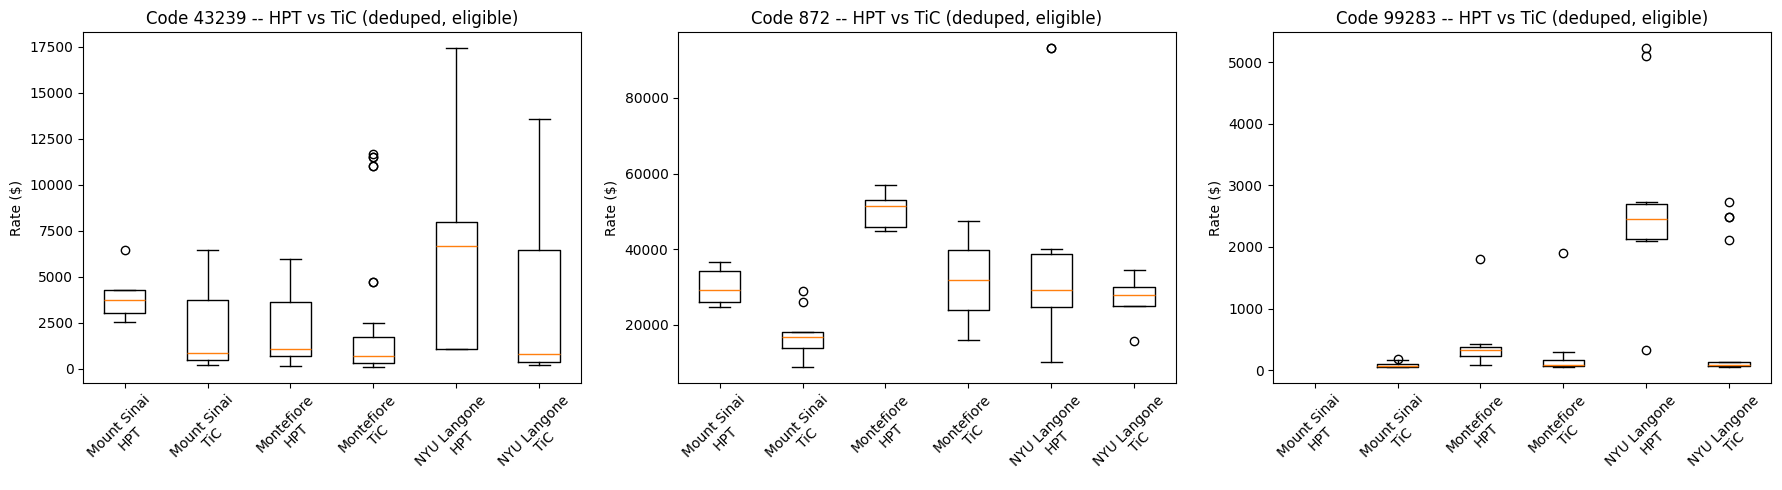

In [28]:
import matplotlib.pyplot as plt

## -- EXPLORATORY VISUALIZATION: rate distributions by code/hospital
SHORT_HOSPITAL_NAMES = {
    "131740114": "Montefiore",
    "131624096": "Mount Sinai",
    "133971298": "NYU Langone",
}

def plot_rate_distributions(hpt_dedup, tic_dedup):
    codes = sorted(set(hpt_dedup["code_clean"]) | set(tic_dedup["code_clean"]))
    eins = sorted(SHORT_HOSPITAL_NAMES)

    fig, axes = plt.subplots(1, len(codes), figsize=(6 * len(codes), 5))
    if len(codes) == 1:
        axes = [axes]

    for ax, code in zip(axes, codes):
        data, labels = [], []
        for ein in eins:
            hosp = SHORT_HOSPITAL_NAMES[ein]
            hpt_rates = hpt_dedup.loc[
                (hpt_dedup["code_clean"] == code) & (hpt_dedup["ein"] == ein), "hpt_rate"
            ].dropna().tolist()
            tic_rates = tic_dedup.loc[
                (tic_dedup["code_clean"] == code) & (tic_dedup["ein"] == ein), "tic_rate"
            ].dropna().tolist()
            data.append(hpt_rates or [float("nan")])
            labels.append(f"{hosp}\nHPT")
            data.append(tic_rates or [float("nan")])
            labels.append(f"{hosp}\nTiC")

        ax.boxplot(data, tick_labels=labels)
        ax.set_title(f"Code {code} -- HPT vs TiC (deduped, eligible)")
        ax.set_ylabel("Rate ($)")
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

plot_rate_distributions(hpt_dedup, tic_dedup)

## Visualization insights

The boxplots above (HPT vs. TiC deduped, eligible rates by hospital and code)
provide a quick visual check on *why* certain hospital/payer/code groups
match well and others don't:

- **CPT 43239 (endoscopy/biopsy)** — HPT and TiC ranges broadly overlap at
  Mount Sinai and Montefiore, consistent with the `exact`/`high` confidence
  matches found for this code. NYU shows a much wider spread on both sides
  (HPT up to ~$17K, TiC up to ~$13.5K) — overlapping but noisy, likely
  reflecting multiple plan-tier rates bundled together.

- **CPT 99283 (ED visit, level 3)** — Montefiore and NYU show some overlap
  in the lower range, though NYU's HPT box sits noticeably higher with
  several high outliers (~$5K) against TiC's tightly clustered low values —
  a likely source of `low`-confidence matches. **Mount Sinai's HPT box is
  empty**: its only big-3-labeled rows for this code are Medicare Advantage
  plans, excluded as `excluded_non_commercial_plan`, so there's nothing
  eligible to compare against TiC.

- **MS-DRG 872 (sepsis case rate)** — Montefiore's HPT rates (~45K-55K)
  sit entirely above its TiC rates (~15K-40K), with **no overlap** — this
  is the group that lands in `no_tic_for_key` for Aetna (zero TiC rows for
  that hospital/DRG combination). Mount Sinai and NYU show better overlap,
  though NYU has a single extreme HPT outlier (~$90K).

**Takeaway**: distribution overlap is a reasonable visual proxy for match
quality — groups with overlapping HPT/TiC ranges (43239 at most hospitals)
produce higher-confidence matches, while groups with disjoint ranges or
missing eligible data (872 at Montefiore, 99283 at Mount Sinai) explain most
of the `no_tic_for_key` and `low`-confidence cases in the output.

## Build The Matching Model

### Group-Level Outer Join (Block Key)

Before comparing individual rates, check which (ein, payer, code, code_type, 
billing_class) combinations exist on each side at all — ignoring rate value.

HPT has 28 groups, TiC has 35 groups, 21 overlap. The non-overlapping groups 
(7 HPT-only, 14 TiC-only) represent 18 HPT rows and 63 TiC rows that have no 
counterpart group on the other side — these can never be matched regardless 
of rate, since the hospital/payer/code/billing_class combination itself 
doesn't exist on the other side.

In [29]:
# ───────────────── GROUP-LEVEL OUTER JOIN ON BLOCK_KEY ─────────────────
# Determine which BLOCK_KEY combinations exist on each side. This is a
# *group-level* join (ignores rate) -- it tells us whether the
# ein/payer/code/code_type/billing_class combination exists at all on
# the other side, separate from whether any individual rate matches.
BLOCK_COLS = ["ein", "payer_canonical", "code_clean", "code_type", "billing_class"]

hpt_dedup["_block"] = list(zip(*[hpt_dedup[c] for c in BLOCK_COLS]))
tic_dedup["_block"] = list(zip(*[tic_dedup[c] for c in BLOCK_COLS]))

hpt_groups = set(hpt_dedup["_block"].unique())
tic_groups = set(tic_dedup["_block"].unique())

both_groups = hpt_groups & tic_groups
hpt_only_groups = hpt_groups - tic_groups
tic_only_groups = tic_groups - hpt_groups

print(f"[Step 7] BLOCK_KEY groups -- HPT: {len(hpt_groups)} | TiC: {len(tic_groups)}")
print(f"[Step 7] Groups in both: {len(both_groups)} | "
      f"HPT-only groups: {len(hpt_only_groups)} | "
      f"TiC-only groups: {len(tic_only_groups)}")

[Step 7] BLOCK_KEY groups -- HPT: 28 | TiC: 35
[Step 7] Groups in both: 21 | HPT-only groups: 7 | TiC-only groups: 14


In [30]:
# These never enter price matching -- the ein/payer/code/billing_class
# combination simply isn't present on the other side at all (e.g. the
# classic "DRG rate filed by the hospital but absent from the payer's
# TiC file" case).
EIN_TO_HOSPITAL = hpt.groupby("ein")["hospital_name"].first().to_dict()

hpt_only_rows = hpt_dedup[hpt_dedup["_block"].isin(hpt_only_groups)].copy()
hpt_only_rows["match_category"] = "no_tic_for_key"
hpt_only_rows["data_source"] = "hpt_only"

tic_only_rows = tic_dedup[tic_dedup["_block"].isin(tic_only_groups)].copy()
tic_only_rows["match_category"] = "no_hpt_for_key"
tic_only_rows["data_source"] = "tic_only"
tic_only_rows["hospital_name"] = tic_only_rows["ein"].map(EIN_TO_HOSPITAL)

print(f"[Step 8] HPT rate records with no TiC counterpart group: {len(hpt_only_rows)}")
print(f"[Step 8] TiC rate records with no HPT counterpart group: {len(tic_only_rows)}")

[Step 8] HPT rate records with no TiC counterpart group: 18
[Step 8] TiC rate records with no HPT counterpart group: 63


In [31]:
# Look at HPT-only groups — rates with no TiC counterpart group at all
print("=== HPT-only rows (no TiC group exists) ===")
print(hpt_only_rows[["hospital_name","payer_canonical","code_clean","code_type",
                      "billing_class","hpt_rate",
                      "associated_plans"]].to_string())

print("\n=== TiC-only rows (no HPT group exists) ===")
print(tic_only_rows[["hospital_name","payer_canonical","code_clean","code_type",
                      "billing_class","tic_rate",
                      "associated_networks"]].to_string())

=== HPT-only rows (no TiC group exists) ===
                hospital_name    payer_canonical code_clean code_type  billing_class  hpt_rate                                                                                                                                                                                                                                                                                                                                                  associated_plans
6    The Mount Sinai Hospital  cigna-corporation      43239       CPT  institutional   4289.89                                                                                                                                                                                                                                                                                                                                                     [HMO and PPO]
15  Montefiore Medical Center              aetna        87

### Notable Patterns in Unmatched Groups

- TiC-only rows are almost entirely professional (61/63) — direct result 
  of the billing_class imbalance: HPT barely reports professional rates 
  (21 total), so TiC's professional population mostly has no HPT counterpart.

- Confirms the brief's DRG 872 hint: Montefiore/Aetna/DRG872/institutional 
  ($45,907.79, "Commercial" plan) and NYU/Aetna/DRG872 (4 plan-tier rates, 
  10K-93K) have no TiC group at all — Aetna's PPO MRF doesn't report 
  facility-specific DRG rates for these hospitals.

- NYU/Aetna/CPT43239/professional ranges $174-13,583 (78x spread) under 
  the same network — likely per-NPI physician-specific rates, not error.

- One reversed case: Montefiore/UHC/43239/institutional = $11,677 exists 
  in TiC but HPT has no institutional UHC group for this code at all — 
  possible HPT file incompleteness for this payer/code combination.

### Price Matching Within Matched Groups

For each (ein, payer, code, code_type, billing_class) group present on both 
sides, greedily pair HPT and TiC rates by price proximity — highest-scoring 
pair claims first, each rate used at most once. Confidence is banded by 
delta: exact (<0.5%), high (<5%), medium (<20%), low (≥20%).

Leftover rates (e.g. 1 HPT rate vs. 5 TiC plan-specific rates in the same 
group) are kept as `additional_rate_variant` rather than discarded — these 
represent real plan/NPI-level granularity differences, not unmatched data.

Sanity check confirms every HPT and TiC row in a matched group ends up either 
paired or labeled as an additional variant, with no loss or duplication.

### On Confidence Bands vs. Hard Thresholds

This matching approach does not apply a minimum confidence threshold for 
acceptance. Within each matched block, every available rate is paired with 
its closest counterpart by price proximity — even if the best available 
match has a large delta (confidence_band = "low"). 

This is a deliberate choice: rather than arbitrarily declaring some pairs 
"unmatched" via a cutoff, every match receives a transparent confidence 
label, and downstream users can threshold on confidence_band as needed for 
their use case. A "low" confidence match still conveys useful information — 
it tells the user that within this hospital/payer/code/billing_class block, 
this is the closest available comparison, even if it likely reflects a 
different plan tier, NPI-specific carve-out, or other granularity mismatch 
rather than the same underlying contract.

In [32]:
# ───────────────── PRICE MATCHING WITHIN "BOTH" GROUPS─────────────────
# For each BLOCK_KEY group present on both sides: greedily pair HPT rates
# to TiC rates by price proximity (highest-scoring pair claims first,
# each rate used at most once). Paired rows -> "matched" with a confidence
# band from the rate delta. Any leftover rates (granularity mismatch,
# e.g. 1 HPT rate vs. 5 TiC plan-specific rates) -> "additional_rate_variant".

def price_score(h, t):
    return 1 - abs(h - t) / max(h, t)

def confidence_band(abs_delta_pct):
    if abs_delta_pct < 0.5:
        return "exact"
    if abs_delta_pct < 5:
        return "high"
    if abs_delta_pct < 20:
        return "medium"
    return "low"

matched_rows = []
additional_rows = []

hpt_both = hpt_dedup[hpt_dedup["_block"].isin(both_groups)]
tic_both = tic_dedup[tic_dedup["_block"].isin(both_groups)]

for block_key, hpt_grp in hpt_both.groupby("_block"):
    tic_grp = tic_both[tic_both["_block"] == block_key]

    h_records = hpt_grp.to_dict("records")
    t_records = tic_grp.to_dict("records")

    # All candidate pairs, scored by price proximity, best first
    pairs = []
    for hi, h in enumerate(h_records):
        for ti, t in enumerate(t_records):
            pairs.append((price_score(h["hpt_rate"], t["tic_rate"]), hi, ti))
    pairs.sort(key=lambda x: x[0], reverse=True)

    used_h, used_t = set(), set()
    for score, hi, ti in pairs:
        if hi in used_h or ti in used_t:
            continue
        used_h.add(hi)
        used_t.add(ti)

        h, t = h_records[hi], t_records[ti]
        delta_pct = round((t["tic_rate"] - h["hpt_rate"]) / h["hpt_rate"] * 100, 2)
        abs_delta = abs(delta_pct)

        row = {**h, **t}
        row["rate_delta_pct"] = delta_pct
        row["abs_delta_pct"] = abs_delta
        row["match_confidence"] = confidence_band(abs_delta)
        row["match_category"] = "matched"
        row["data_source"] = "both"
        matched_rows.append(row)

    # Leftover HPT rates: key matched, but no TiC rate left to pair with
    for hi, h in enumerate(h_records):
        if hi not in used_h:
            row = dict(h)
            row["match_category"] = "additional_rate_variant"
            row["data_source"] = "hpt_only"
            additional_rows.append(row)

    # Leftover TiC rates: key matched, but no HPT rate left to pair with
    for ti, t in enumerate(t_records):
        if ti not in used_t:
            row = dict(t)
            row["hospital_name"] = EIN_TO_HOSPITAL.get(row["ein"])
            row["match_category"] = "additional_rate_variant"
            row["data_source"] = "tic_only"
            additional_rows.append(row)

matched_df = pd.DataFrame(matched_rows)
additional_df = pd.DataFrame(additional_rows)

n_additional_hpt = (additional_df["data_source"] == "hpt_only").sum() if len(additional_df) else 0
n_additional_tic = (additional_df["data_source"] == "tic_only").sum() if len(additional_df) else 0

print(f"'Both' groups processed: {len(both_groups)}")
print(f" Matched pairs: {len(matched_df)}")
print(f"confidence band breakdown:")
print(matched_df["match_confidence"].value_counts())
print(f"Additional rate variants -- HPT side: {n_additional_hpt} | "
      f"TiC side: {n_additional_tic}")

# Sanity -- every HPT/TiC dedup row in a "both" group ends up either
# matched or as an additional_rate_variant, with no loss/duplication
print(f"Sanity -- HPT 'both' rows: {len(hpt_both)} = "
      f"matched ({len(matched_df)}) + additional_hpt ({n_additional_hpt}) "
      f"= {len(matched_df) + n_additional_hpt}")
print(f"Sanity -- TiC 'both' rows: {len(tic_both)} = "
      f"matched ({len(matched_df)}) + additional_tic ({n_additional_tic}) "
      f"= {len(matched_df) + n_additional_tic}")
assert len(hpt_both) == len(matched_df) + n_additional_hpt
assert len(tic_both) == len(matched_df) + n_additional_tic

'Both' groups processed: 21
 Matched pairs: 42
confidence band breakdown:
match_confidence
low       19
exact     10
medium     7
high       6
Name: count, dtype: int64
Additional rate variants -- HPT side: 7 | TiC side: 62
Sanity -- HPT 'both' rows: 49 = matched (42) + additional_hpt (7) = 49
Sanity -- TiC 'both' rows: 104 = matched (42) + additional_tic (62) = 104


## Final Output Aggregate

In [33]:
# -- ASSEMBLE EXCLUDED-ROW OUTPUT 

hpt_excluded_out = hpt_excluded.copy()
hpt_excluded_out["hpt_rate"] = hpt_excluded_out["standard_charge_negotiated_dollar"]
hpt_excluded_out["hpt_plan_names"] = hpt_excluded_out["plan_name"].apply(lambda x: [x] if pd.notna(x) else [])
hpt_excluded_out["hpt_descriptions"] = hpt_excluded_out["description"].apply(lambda x: [x] if pd.notna(x) else [])
hpt_excluded_out["hpt_settings"] = hpt_excluded_out["setting"].apply(lambda x: [x] if pd.notna(x) else [])
hpt_excluded_out["hpt_methodologies"] = hpt_excluded_out["standard_charge_methodology"].apply(lambda x: [x] if pd.notna(x) else [])
hpt_excluded_out["hpt_gross_charges"] = hpt_excluded_out["standard_charge_gross"].apply(lambda x: [x] if pd.notna(x) else [])
hpt_excluded_out["n_hpt_source_rows"] = 1
hpt_excluded_out["match_category"] = hpt_excluded_out["match_eligibility"]
hpt_excluded_out["data_source"] = "hpt_only"

print(f"Excluded HPT rows carried to output as-is: {len(hpt_excluded_out)}")


# ───────────────── FINAL ASSEMBLY INTO UNIFIED SCHEMA ─────────────────

FINAL_COLS = [
    "data_source", "match_category", "match_confidence",
    "ein", "hospital_name", "payer_canonical", "code_clean", "code_type", "billing_class",
    "hpt_rate", "tic_rate", "rate_delta_pct", "abs_delta_pct",
    "n_hpt_source_rows", "n_tic_source_rows",
    "hpt_plan_names", "hpt_descriptions", "hpt_settings", "hpt_methodologies", "hpt_gross_charges",
    "tic_network_names", "tic_npi_lists", "tic_modifiers", "tic_pos",
    "tic_negotiation_types", "tic_arrangements",
    "cms_baseline_rate", "cms_baseline_schedule",
]

pieces = [hpt_excluded_out, hpt_only_rows, tic_only_rows, matched_df, additional_df]
pieces = [p.reindex(columns=FINAL_COLS) for p in pieces if len(p) > 0]

final = pd.concat(pieces, ignore_index=True)

print(f"Final unified dataset: {len(final)} rows, {len(final.columns)} columns")
print("match_category distribution:")
print(final["match_category"].value_counts())
print("data_source distribution:")
print(final["data_source"].value_counts())

Excluded HPT rows carried to output as-is: 2663
Final unified dataset: 2855 rows, 28 columns
match_category distribution:
match_category
excluded_non_big3_payer             2577
additional_rate_variant               69
no_hpt_for_key                        63
excluded_local_code_inconsistent      52
matched                               42
excluded_non_commercial_plan          22
no_tic_for_key                        18
excluded_missing_negotiated_rate      12
Name: count, dtype: int64
data_source distribution:
data_source
hpt_only    2688
tic_only     125
both          42
Name: count, dtype: int64


### Steps Completed

1. Categorized HPT rows into eligible vs excluded (non-big-3 payer, LOCAL 
   code inconsistency, non-commercial plans, missing rates)
2. Deduplicated HPT and TiC on (block key + rate), reducing 287/222 source 
   rows to 67/167 unique rate records
3. Block-level outer join on (ein, payer, code, code_type, billing_class) — 
   21 blocks present on both sides, 7 HPT-only, 14 TiC-only
4. Within each matched block, greedily paired HPT and TiC rates by price 
   proximity, with leftover rates retained as additional_rate_variant
5. Assembled all pieces (excluded, hpt_only, tic_only, matched, additional) 
   into one unified schema — 2,855 rows total

### Output Insights

The 2,855-row total is dominated by excluded_non_big3_payer (2,577 rows) — 
this is expected, since HPT covers 73 payer variants while TiC covers only 
the big 3. The genuinely comparable population is small: 42 matched pairs, 
69 additional rate variants, and 81 rows with no counterpart block at all 
(63 no_hpt_for_key + 18 no_tic_for_key).

Confidence distribution among the 42 matches: 10 exact, 6 high, 7 medium, 
19 low. The "low" bucket is the largest single group — but this doesn't 
mean these are bad matches, as the next section explains.

### Low/Medium Confidence Matches Are Not Failures — They're Anchors for Comparison

Take Mount Sinai / Aetna / CPT 43239 / institutional: HPT reports 2,513.89, 
matched to TiC's 1,766.00 (29.75% delta, "low" confidence). At first glance 
this looks like a poor match.

But the same block has an additional_rate_variant: a TiC-only rate of 
$5,845.00 for a single NPI (1013948595, 1245248939, 1669476156 — three 
providers). The matched 1,766 rate applies to a much broader NPI list 
(six providers, including different NPIs entirely).

This is the real picture: within one (hospital, payer, code, billing_class) 
block, there isn't one "correct" answer — there are multiple legitimately 
different negotiated rates depending on which provider/NPI is billing. The 
"matched" row with low confidence isn't a failed match — it's the closest 
price anchor, while the additional_rate_variant rows are siblings showing 
the actual range of rates Aetna negotiates with different providers at the 
same facility for the same code.

For a downstream user (e.g. an employer benchmarking contracts), the value 
isn't "is $2,513.89 == 1,766.00" — it's "Aetna's institutional rate for 
CPT 43239 at Mount Sinai ranges from 1,766 to 5,845 depending on which 
provider bills it, and HPT's reported 2,513.89 falls within that range." 
The matched + additional_rate_variant rows together tell this story; either 
one alone would be incomplete.

### Future Refinements — Beyond Price Proximity

Due to time constraints, the current matching model uses price proximity as 
the sole confidence signal. With more time, several additional features could 
refine confidence scoring without changing the core matching architecture:

**Plan/network alignment** — compare HPT's plan_name against TiC's 
associated_networks for the matched pair. A match where HPT's plan name 
("PPO", "Choice Plus") semantically aligns with TiC's network designation 
should receive a confidence boost over a match where they appear unrelated.

**Rate methodology alignment** — compare HPT's standard_charge_methodology 
(case rate, fee schedule, % of billed charges) against TiC's negotiation_type. 
Matches where both sides report the same rate structure (e.g. both "fee 
schedule") are more likely to represent the same contract than matches where 
the structures differ (e.g. HPT case rate vs TiC fee schedule) — even if the 
dollar values happen to be close.

**Date gap as a confidence factor** — HPT and TiC files are updated on 
different schedules; payers publish MRFs monthly while hospitals update HPT 
files less frequently. In this dataset:
- NYU Langone: 0-day gap (both January 2025) — highest temporal confidence
- Mt Sinai: ~105-day gap (September 2024 vs January 2025) — minor drift possible
- Montefiore: ~184-day gap (July 2024 vs January 2025) — most susceptible to 
  contract escalator drift

Smaller date gaps should increase confidence, since a larger gap allows more 
room for legitimate rate drift (e.g. annual escalator clauses) to explain an 
otherwise-moderate delta.

**Combining signals** — these three factors (plan/network alignment, 
methodology alignment, date gap) would not replace price proximity but would 
adjust it — e.g. a "low" price-confidence match that also has aligned 
methodology and a 0-day date gap might be upgraded to "medium," while a 
"medium" price match with mismatched methodology and a 184-day gap might be 
downgraded to "low." This moves from a single-signal score toward a small, 
interpretable multi-factor confidence model — the natural next step once the 
core matching logic is validated.